In [ ]:
import warnings
warnings.simplefilter(action='ignore')

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import torch
import scarches as sca
import sys

 captum (see https://github.com/pytorch/captum).


In [ ]:
sc.set_figure_params(frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(4, 4))
torch.set_printoptions(precision=3, sci_mode=False, edgeitems=7)

In [4]:
!ls

Miniconda3-latest-Linux-x86_64.sh  cache  git	      scripts  snap
binary_matrix_summary.txt	   def	  miniconda3  sif


In [ ]:
perc = 1
top_genes = 2000

adata_path = f'/home/lgolinelli/git/scarches-1/notebooks/GRN-VAE/anndata_inputs/adata_top_{perc}_top_genes_{top_genes}.h5ad'
model_path = f'/home/lgolinelli/git/scarches-1/notebooks/GRN-VAE/trained_models/model_{perc}_top_genes_{top_genes}_placeholder_condition'

In [6]:
adata = sc.read_h5ad(adata_path)

In [ ]:
adata.obs["placeholder_condition"] = "placeholder"

In [8]:
vae = sca.models.EXPIMAP.load(model_path, adata, map_location='cpu')

AnnData object with n_obs × n_vars = 4544 × 1994
    obs: 'cancer_subtype', 'placeholder_condition'
    var: 'gene_ids', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_idx', 'counts_in_terms', 'gene_as_regulator'
    uns: 'cancer_subtype_colors', 'hvg', 'log1p', 'neighbors', 'nsd2_as_regulator', 'nsd2_as_target', 'pca', 'terms', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'I', 'PCs'
    layers: 'X_normalized', 'counts'
    obsp: 'connectivities', 'distances'

INITIALIZING NEW NETWORK..............
Encoder Architecture:
	Input Layer in, out and cond: 1994 300 1
	Hidden Layer 1 in/out: 300 300
	Hidden Layer 2 in/out: 300 300
	Mean/Var Layer in/out: 300 2212
Decoder Architecture:
	Masked linear layer in, ext_m, ext, cond, out:  2212 0 0 1 1994
	with hard mask.
Last Decoder layer: softmax


In [9]:
vae.nonzero_terms()

array([False, False, False, False, False, False, False, ..., False, False,
       False, False, False, False, False])

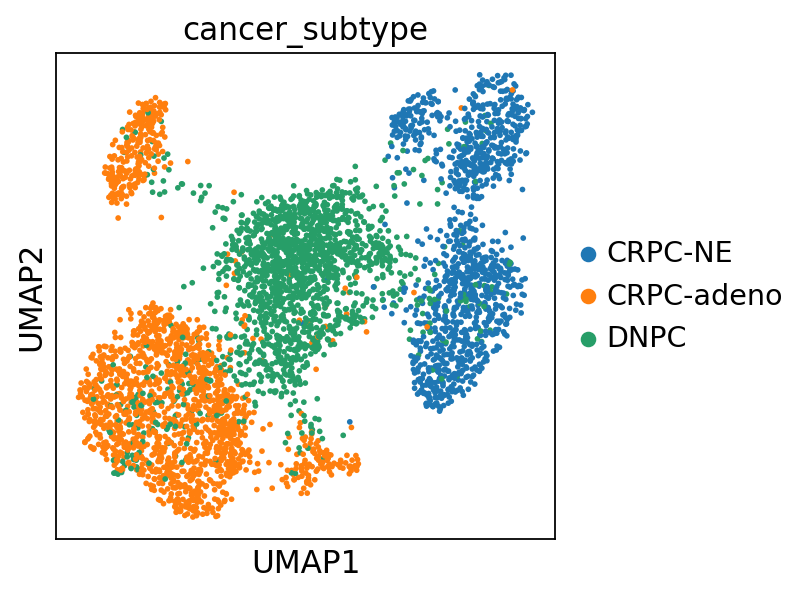

In [10]:
adata.obsm['vae_latent'] = vae.get_latent(
    x=adata.X, 
    c=adata.obs['placeholder_condition'].values,
    only_active=True)

sc.pp.neighbors(adata, use_rep='vae_latent')

sc.tl.umap(adata)
sc.pl.umap(adata, color='cancer_subtype')

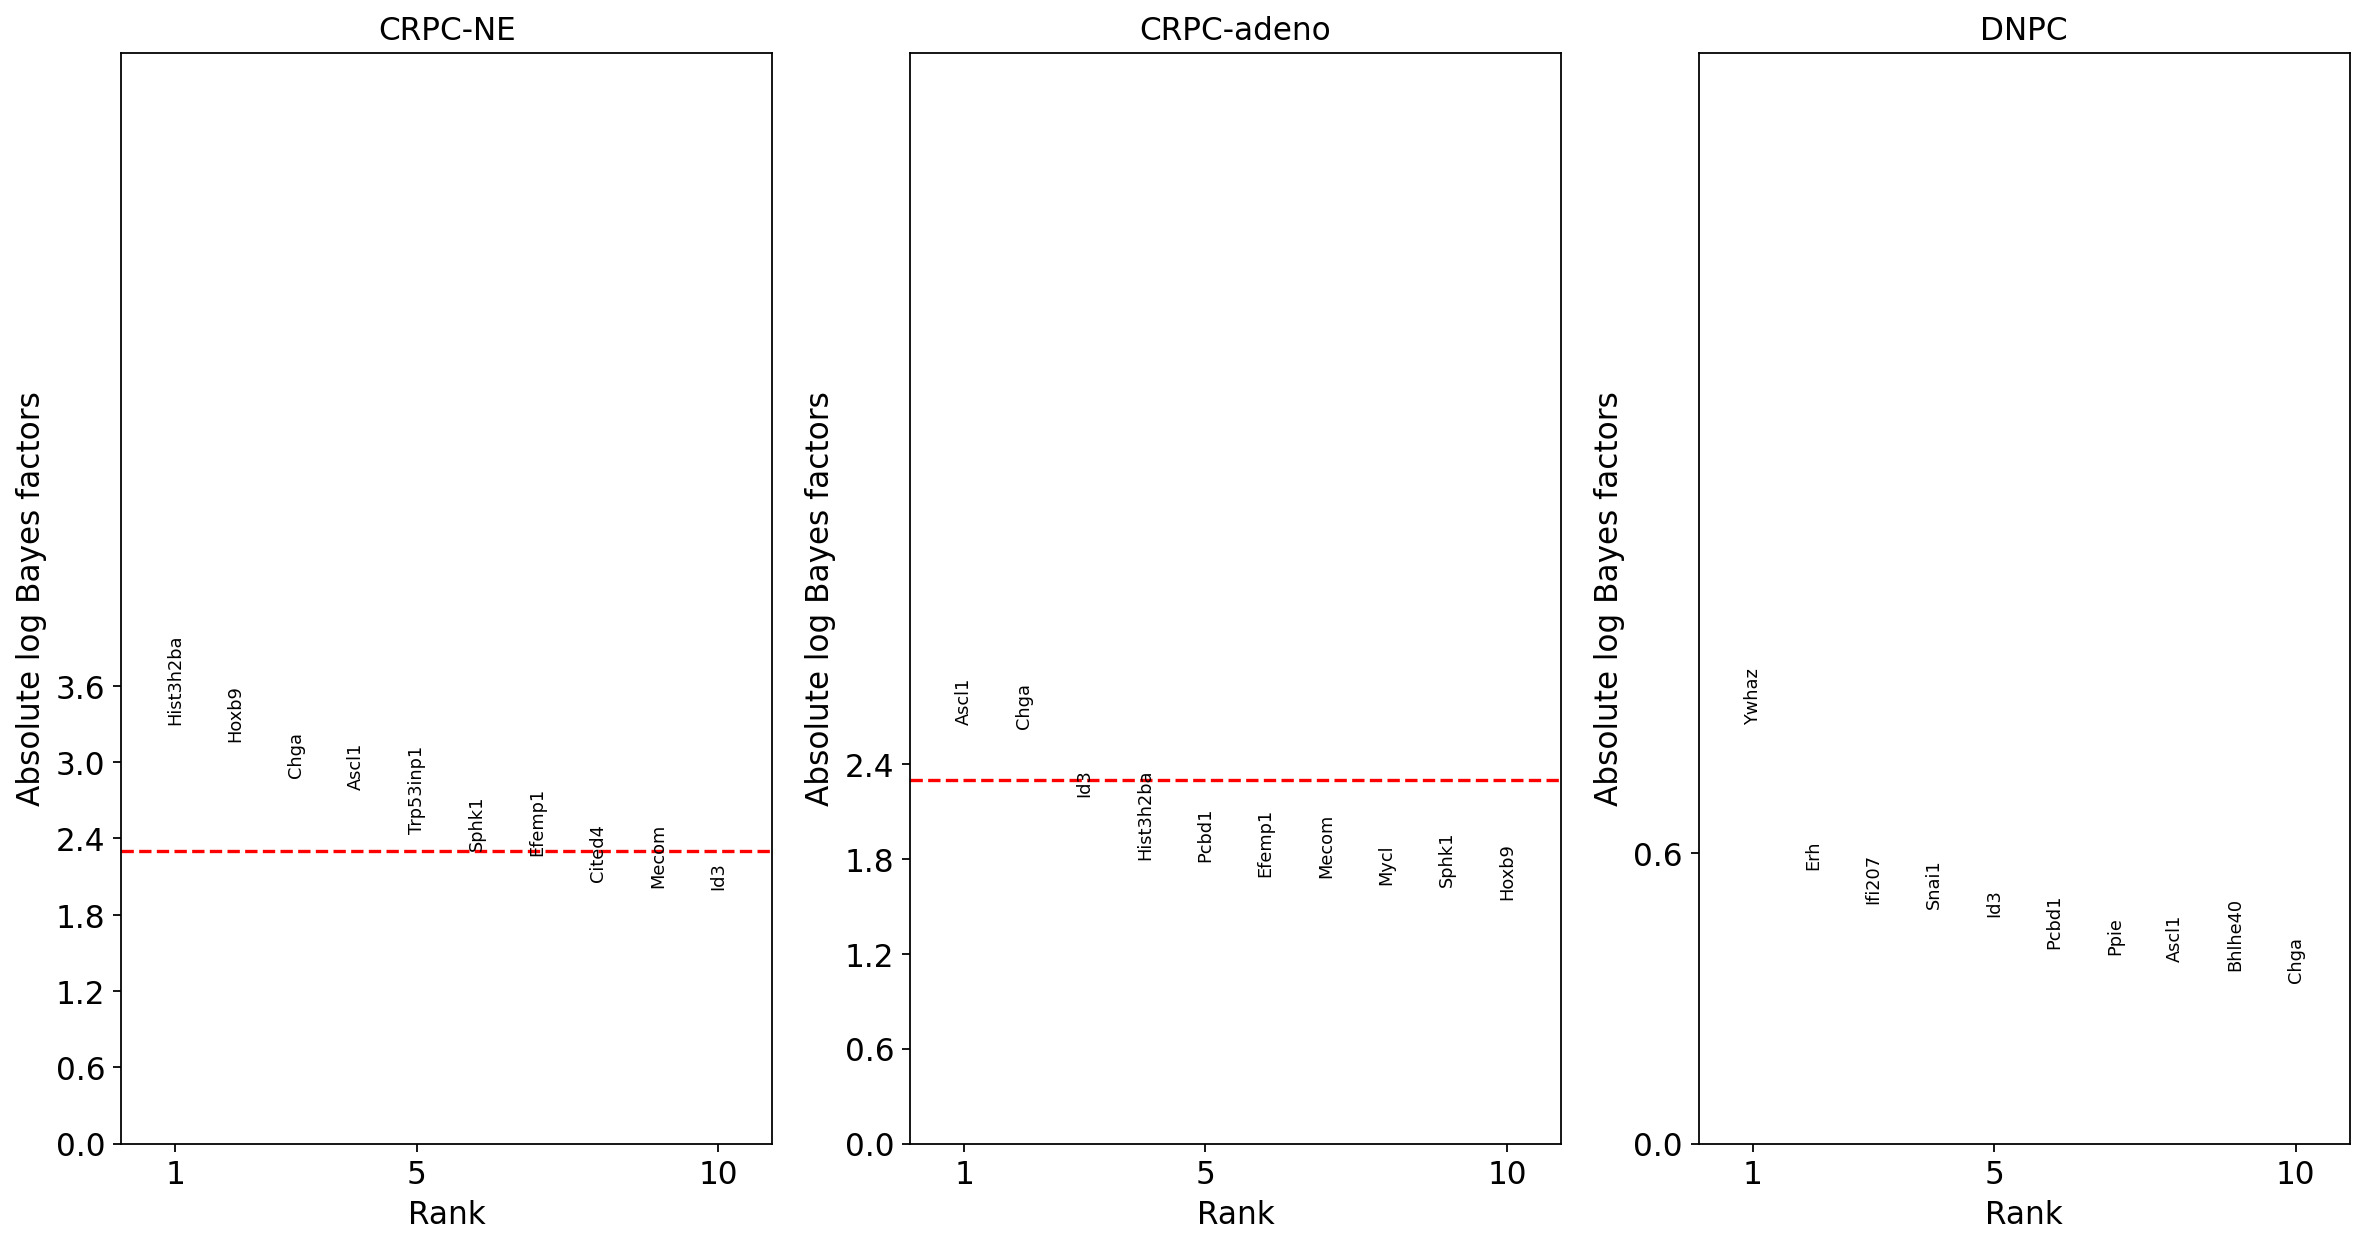

In [11]:
vae.latent_directions(adata=adata)
n_samples = min(adata.obs['cancer_subtype'].value_counts())
vae.latent_enrich(groups='cancer_subtype', use_directions=False, adata=adata, n_sample=n_samples)

fig = sca.plotting.plot_abs_bfs(
    adata,
    n_cols=3,
    scale_y=2.6,
    yt_step=0.6,
    figsize=(15, 8),  # Increase figure size
    n_points=10,
)

In [ ]:
np.histogram(adata[:,'Chga'].X.data)

(array([3007,   82,   14,    2,    2,    2,    0,    0,    0,    2]),
 array([  1.,  40.,  79., 118., 157., 196., 235., 274., 313., 352., 391.],
       dtype=float32))

In [13]:
# 1) Subset & perturb

gene_names = np.load(
    '/home/lgolinelli/git/scarches-1/notebooks/GRN-VAE/genes_perturb/genes_chga.npy',
    allow_pickle=True
)

ne_cells = adata.obs['cancer_subtype'] == 'CRPC-NE'
adata_ne = adata[ne_cells].copy()
# zero‐out the gene “Nsd2” in that subset
#gene_names = ['Chga', 'Insm1', 'Ascl1', 'Foxa2']
gene_names = ['Pcsk2']
gene_idx = [list(adata_ne.var_names).index(gene) for gene in gene_names if gene in adata_ne.var_names]
adata_ne.X[:, gene_idx] = 0
adata_ne.obs['cancer_subtype'] = 'CRPC-NE-NSD2KO'

# 2) Concatenate back
adata_cat = adata.concatenate(
    adata_ne,
    batch_key='perturbation',
    batch_categories=['orig','NSD2_KO']
)

AnnData object with n_obs × n_vars = 1165 × 1994
    obs: 'cancer_subtype', 'placeholder_condition'
    var: 'gene_ids', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_idx', 'counts_in_terms', 'gene_as_regulator'
    uns: 'cancer_subtype_colors', 'hvg', 'log1p', 'neighbors', 'nsd2_as_regulator', 'nsd2_as_target', 'pca', 'terms', 'umap', 'directions', 'bf_scores'
    obsm: 'X_pca', 'X_umap', 'vae_latent'
    varm: 'I', 'PCs'
    layers: 'X_normalized', 'counts'
    obsp: 'connectivities', 'distances'

INITIALIZING NEW NETWORK..............
Encoder Architecture:
	Input Layer in, out and cond: 1994 300 1
	Hidden Layer 1 in/out: 300 300
	Hidden Layer 2 in/out: 300 300
	Mean/Var Layer in/out: 300 2212
Decoder Architecture:
	Masked linear layer in, ext_m, ext, cond, out:  2212 0 0 1 1994
	with hard mask.
Last Decoder layer: softmax


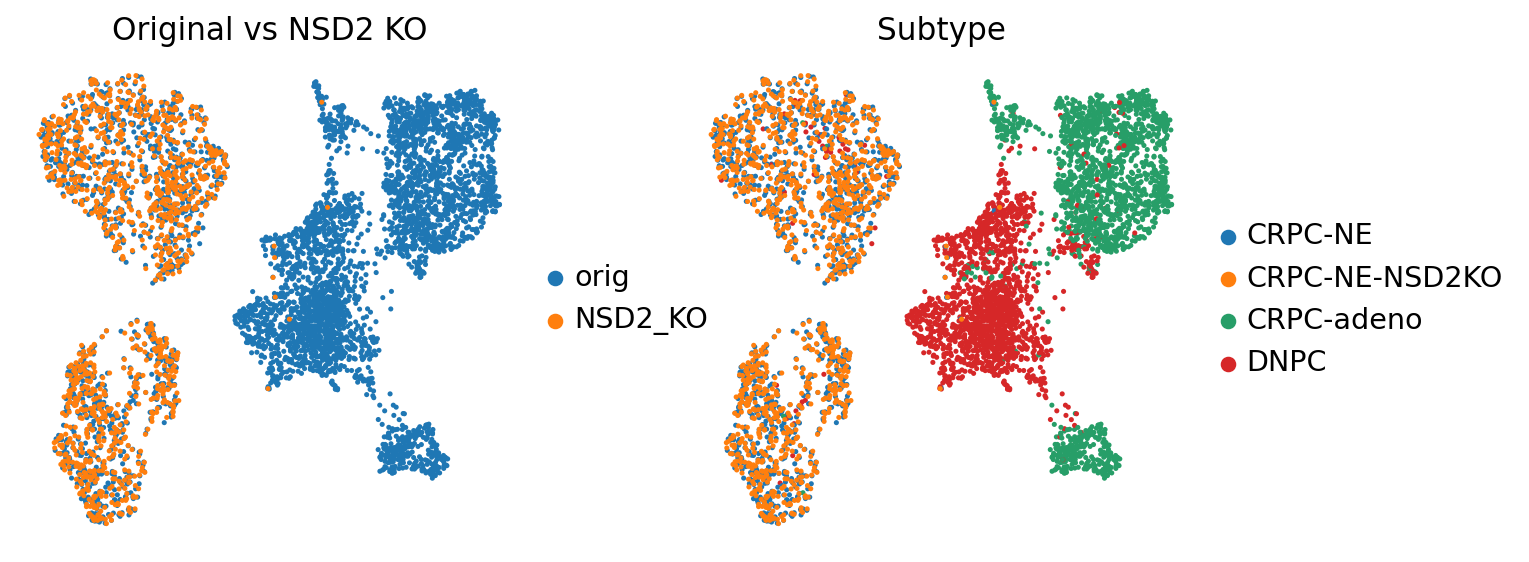

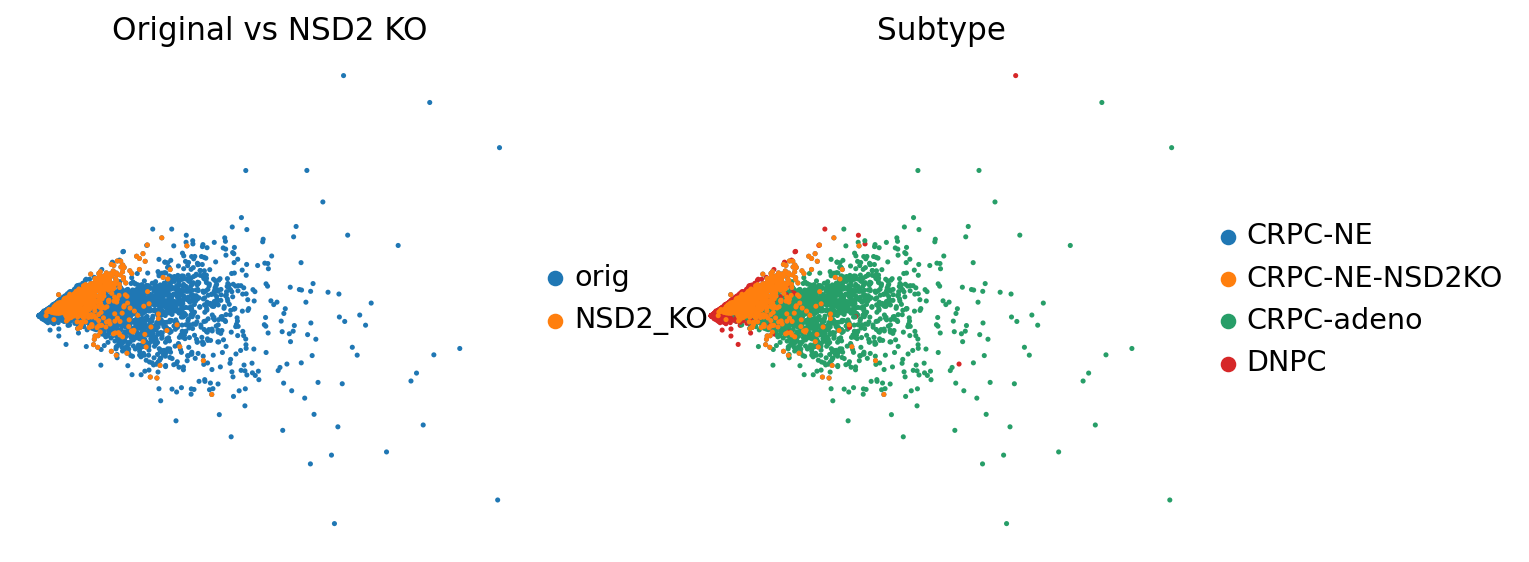

In [14]:
# 3) Load your trained model in frozen/inference‐only mode
model = sca.models.EXPIMAP.load_query_data(
    adata_ne,
    reference_model=model_path,
    freeze=True,
    freeze_expression=True,
    unfreeze_ext=False,
    remove_dropout=True,
    map_location='cpu'
)

# ensure absolutely no gradients
for p in model.model.parameters():
    p.requires_grad = False
model.model.eval()

# 4) Embed everyone into latent space (use the mean for deterministic coords)
z = model.get_latent(
    x=adata_cat.X,
    c=adata_cat.obs[model.condition_key_].values,
    mean=True,
    only_active=True
)

# stash in AnnData.obsm
adata_cat.obsm['X_expimap'] = z

# 5) Neighbors + UMAP
sc.pp.neighbors(adata_cat, use_rep='X_expimap', n_neighbors=15, metric='euclidean')
sc.tl.umap(adata_cat)
sc.tl.pca(adata_cat, n_comps=10)

# 6) Plot, coloring by perturbation batch
sc.pl.umap(
    adata_cat, 
    color=['perturbation','cancer_subtype'],
    title=['Original vs NSD2 KO','Subtype'],
    frameon=False,
    legend_loc='right margin'
)

sc.pl.pca(
    adata_cat, 
    color=['perturbation','cancer_subtype'],
    title=['Original vs NSD2 KO','Subtype'],
    frameon=False,
    legend_loc='right margin'
)

In [15]:
cluster_distances = vae.e_distance(adata_cat, cluster_key='cancer_subtype', embedding_key='X_expimap', n_jobs=-1)

                CRPC-NE  CRPC-NE-NSD2KO  CRPC-adeno   DNPC
CRPC-NE          0.0000          0.0012     11.4477 5.4155
CRPC-NE-NSD2KO                   0.0000     11.4152 5.3927
CRPC-adeno                                   0.0000 3.2292
DNPC                                                0.0000


In [16]:
cluster_distances = vae.e_distance(adata_cat, cluster_key='cancer_subtype', embedding_key='X_expimap', n_jobs=-1)

                CRPC-NE  CRPC-NE-NSD2KO  CRPC-adeno   DNPC
CRPC-NE          0.0000          0.0012     11.4477 5.4155
CRPC-NE-NSD2KO                   0.0000     11.4152 5.3927
CRPC-adeno                                   0.0000 3.2292
DNPC                                                0.0000


In [ ]:
adata_cat.uns['terms'] = adata.uns['terms']

In [18]:
vae.nonzero_terms().sum()

45

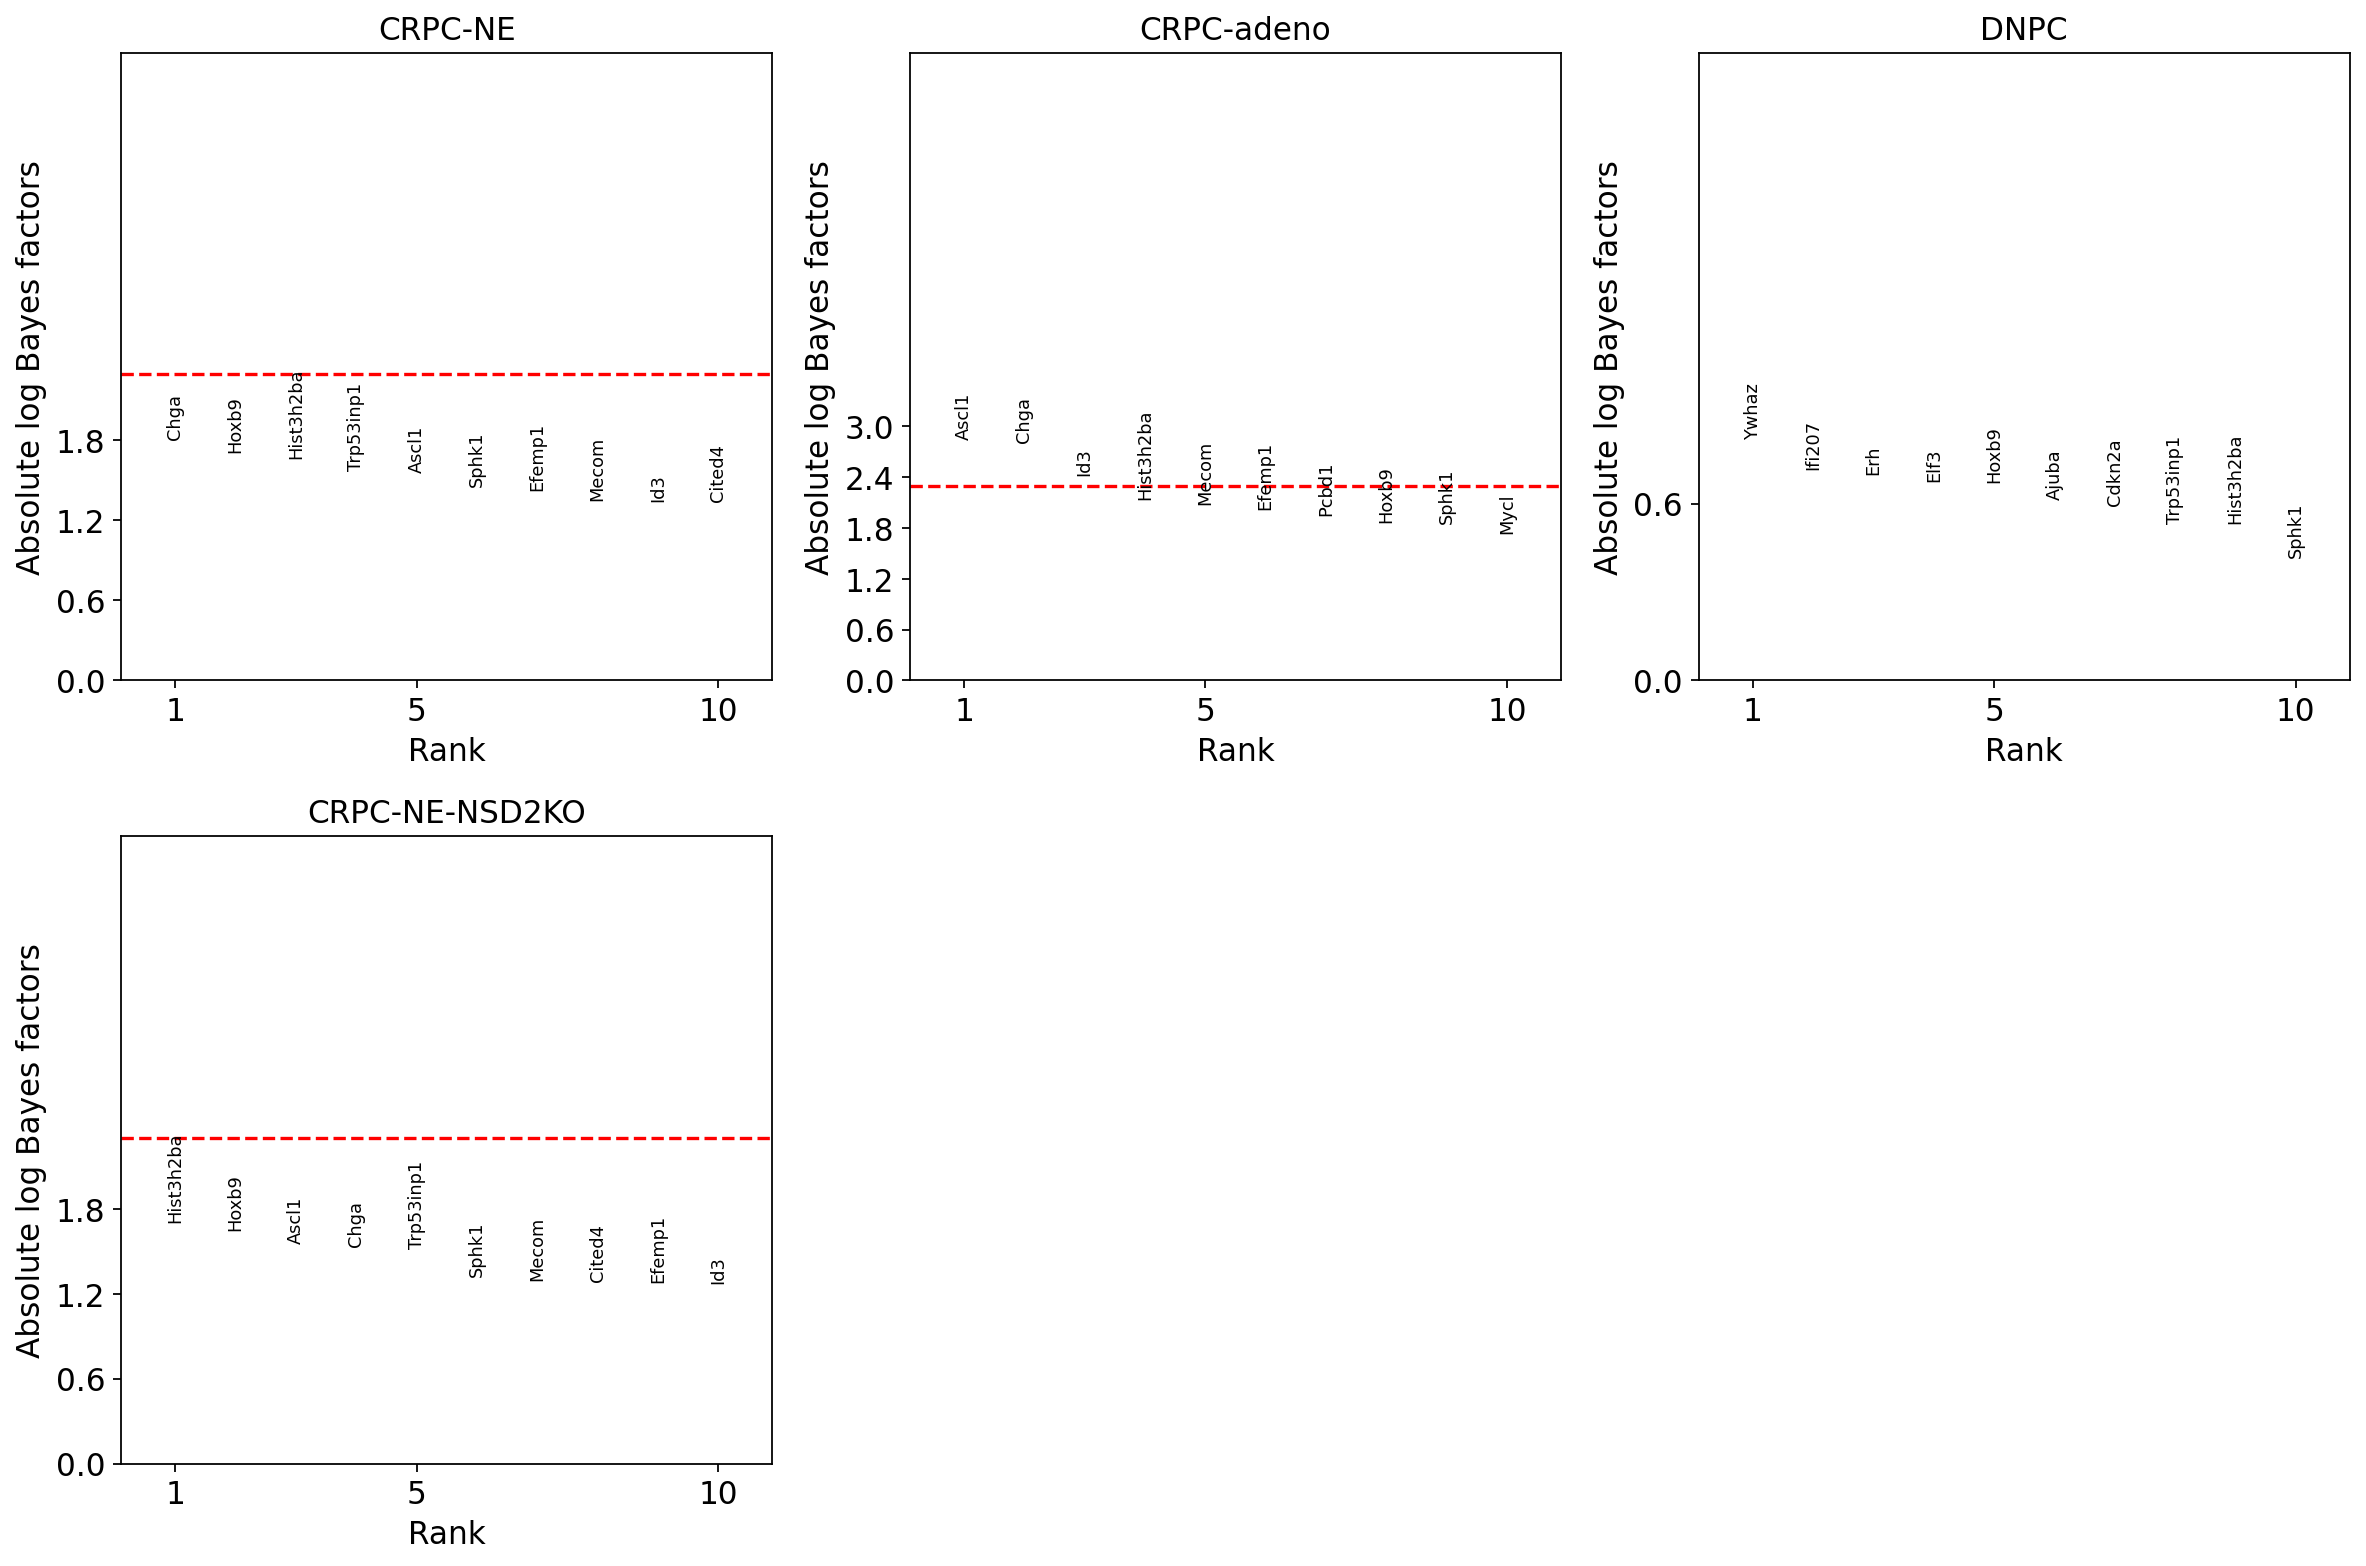

In [19]:
vae.latent_directions(adata=adata_cat)
n_samples = min(adata_cat.obs['cancer_subtype'].value_counts())
vae.latent_enrich(groups='cancer_subtype', use_directions=False, adata=adata_cat, n_sample=n_samples)

fig = sca.plotting.plot_abs_bfs(
    adata_cat,
    n_cols=3,
    scale_y=2.6,
    yt_step=0.6,
    figsize=(15, 10),  # Increase figure size
    n_points=10
)

In [20]:
nonzero_terms = adata.uns['terms'][vae.nonzero_terms()]

adata_gp = sc.AnnData(
    X=adata.obsm['vae_latent'],
    obs=adata.obs,
)

adata_cat_gp = sc.AnnData(
    X=adata_cat.obsm['X_expimap'],
    obs=adata_cat.obs,
    var=nonzero_terms
)

adata_gp.var_names = nonzero_terms
adata_cat_gp.var_names = nonzero_terms


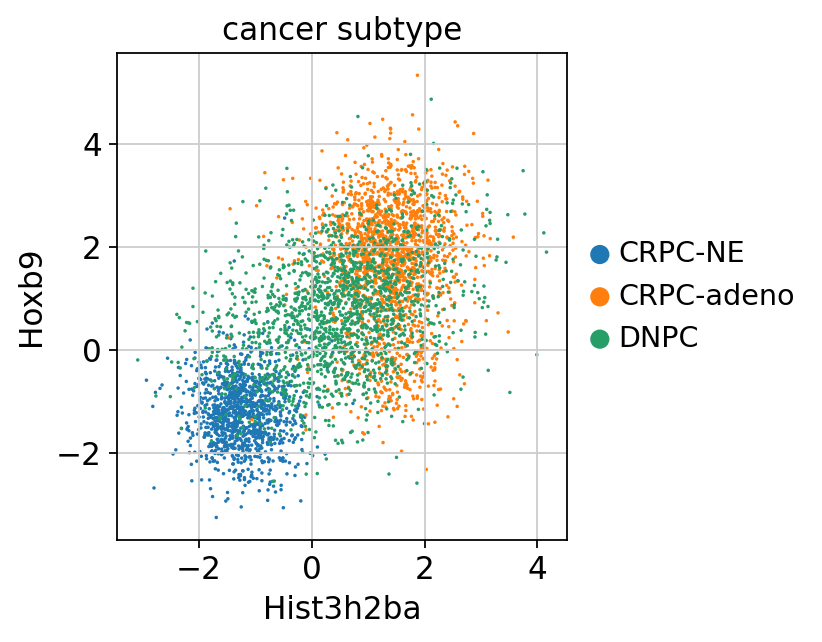

In [21]:
sc.pl.scatter(adata_gp, x='Hist3h2ba', y='Hoxb9', color='cancer_subtype', size=10)

In [22]:
adata_gp.var_names

Index(['Ajuba', 'Anxa4', 'Ascl1', 'Bhlhe40', 'Cdkn2a', 'Cenpa', 'Cenpf',
       'Chga', 'Chgb', 'Cited4', 'Cks2', 'Ebf1', 'Efemp1', 'Ehf', 'Elf3',
       'Erh', 'Gon4l', 'Hist1h2ap', 'Hist3h2ba', 'Hoxb9', 'Hoxd13', 'Id3',
       'Ifi207', 'Junb', 'Mecom', 'Mycl', 'Parp9', 'Pcbd1', 'Ppie', 'Prrx2',
       'Rora', 'Slpi', 'Snai1', 'Snca', 'Sox2', 'Sphk1', 'Stat5a', 'Tet1',
       'Top2a', 'Trp53inp1', 'Wnt4', 'Ywhaz', 'Zeb2', 'Zfp950', 'Zkscan14'],
      dtype='object')

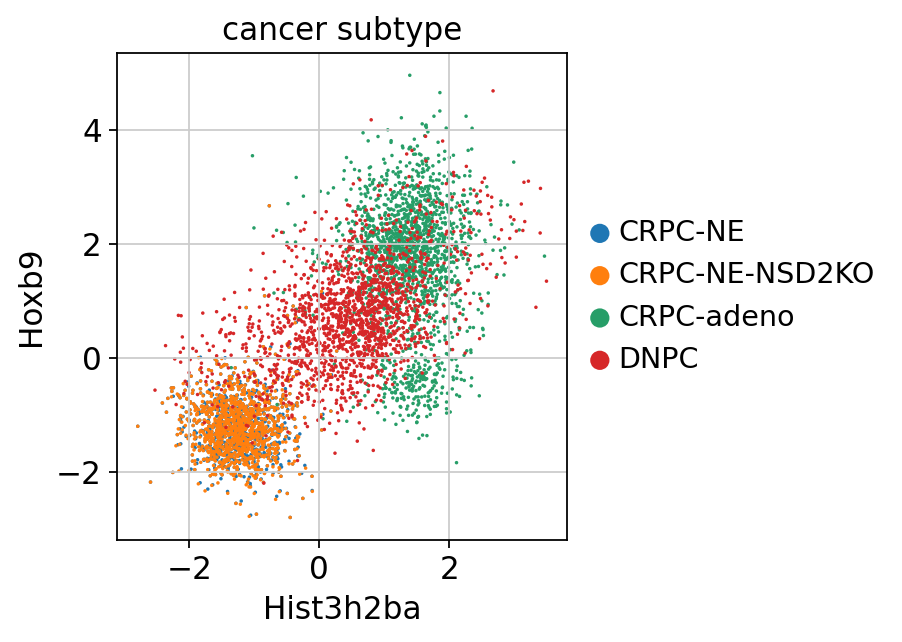

In [23]:
sc.pl.scatter(adata_cat_gp, x='Hist3h2ba', y='Hoxb9', color='cancer_subtype', size=10)

In [24]:
vae.term_genes('Chga', adata.uns['terms'])

,genes,weights,in_mask
0,Pcsk2,0.862898,True
1,Pcsk1,0.806617,True
2,Scg3,0.783092,True
3,Fxyd6,0.763197,True
4,Tmem45b,0.748885,True
5,Chga,0.748057,True
6,Vwf,0.733114,True
7,Gm11716,0.725446,True
8,Scg5,0.684367,True
9,Ttr,0.657561,True


In [25]:
pyviper_path = '/home/lgolinelli/git/scarches-1/notebooks/GRN-VAE/pyviperdata/viperdata_MJ005.h5ad'
pyviperdata = sc.read_h5ad(pyviper_path)
pyviperdata.obs['cancer_subtype'] = adata.obs['cancer_subtype']

In [26]:
adata_gp.var_names

Index(['Ajuba', 'Anxa4', 'Ascl1', 'Bhlhe40', 'Cdkn2a', 'Cenpa', 'Cenpf',
       'Chga', 'Chgb', 'Cited4', 'Cks2', 'Ebf1', 'Efemp1', 'Ehf', 'Elf3',
       'Erh', 'Gon4l', 'Hist1h2ap', 'Hist3h2ba', 'Hoxb9', 'Hoxd13', 'Id3',
       'Ifi207', 'Junb', 'Mecom', 'Mycl', 'Parp9', 'Pcbd1', 'Ppie', 'Prrx2',
       'Rora', 'Slpi', 'Snai1', 'Snca', 'Sox2', 'Sphk1', 'Stat5a', 'Tet1',
       'Top2a', 'Trp53inp1', 'Wnt4', 'Ywhaz', 'Zeb2', 'Zfp950', 'Zkscan14'],
      dtype='object')

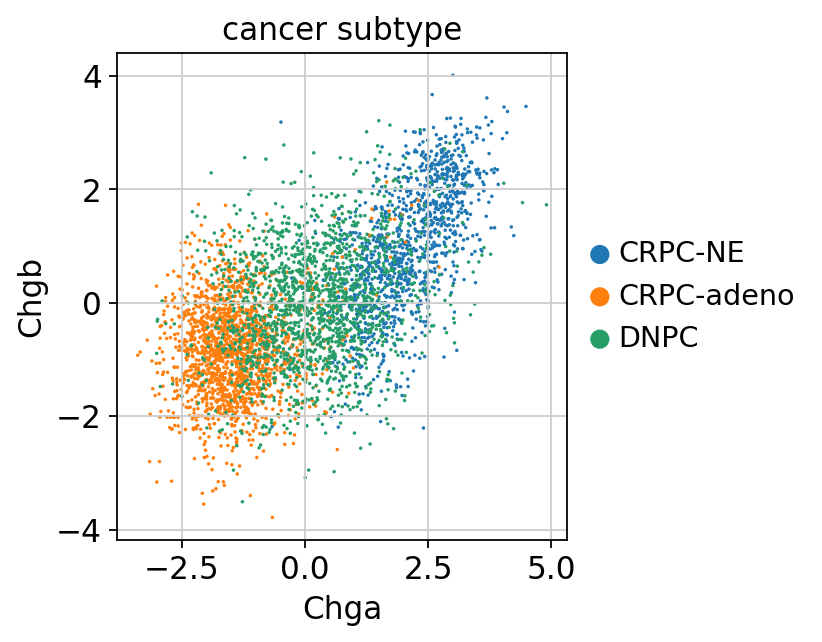

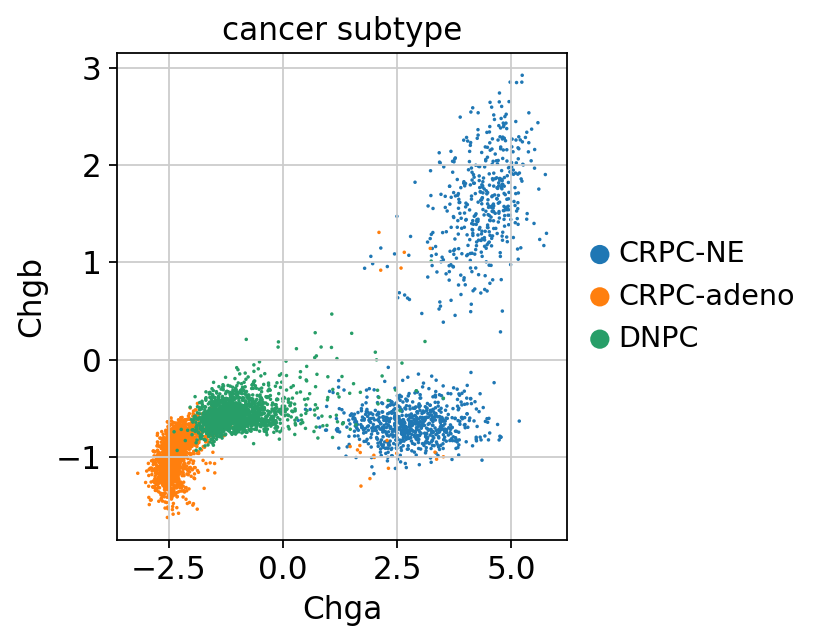

In [27]:
sc.pl.scatter(adata_gp, x='Chga', y='Chgb', color='cancer_subtype', size=10)
sc.pl.scatter(pyviperdata, x='Chga', y='Chgb', color='cancer_subtype', size=10)

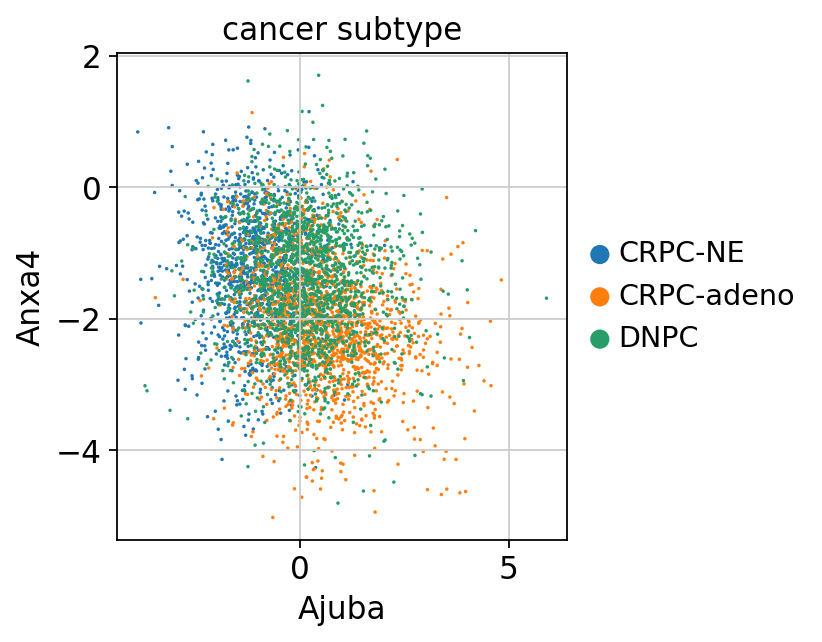

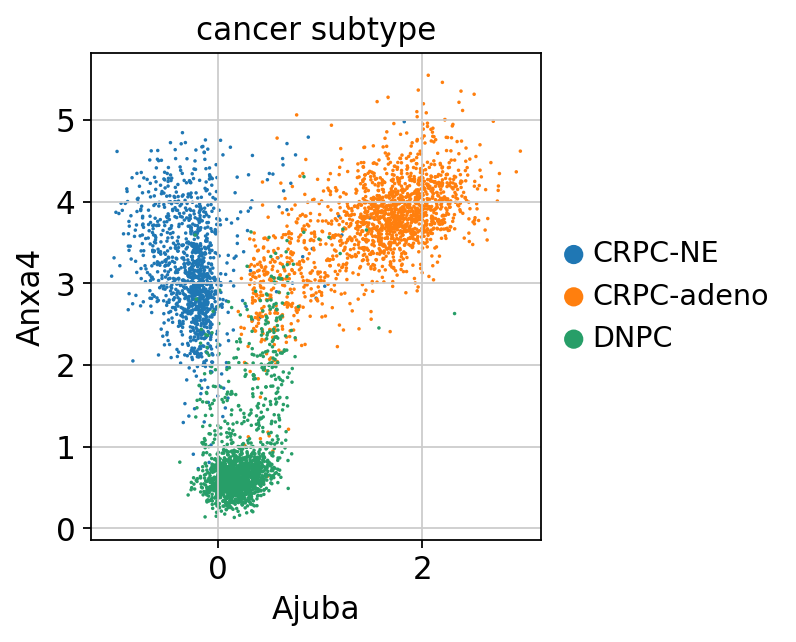

In [28]:
sc.pl.scatter(adata_gp, x='Ajuba', y='Anxa4', color='cancer_subtype', size=10)
sc.pl.scatter(pyviperdata, x='Ajuba', y='Anxa4', color='cancer_subtype', size=10)

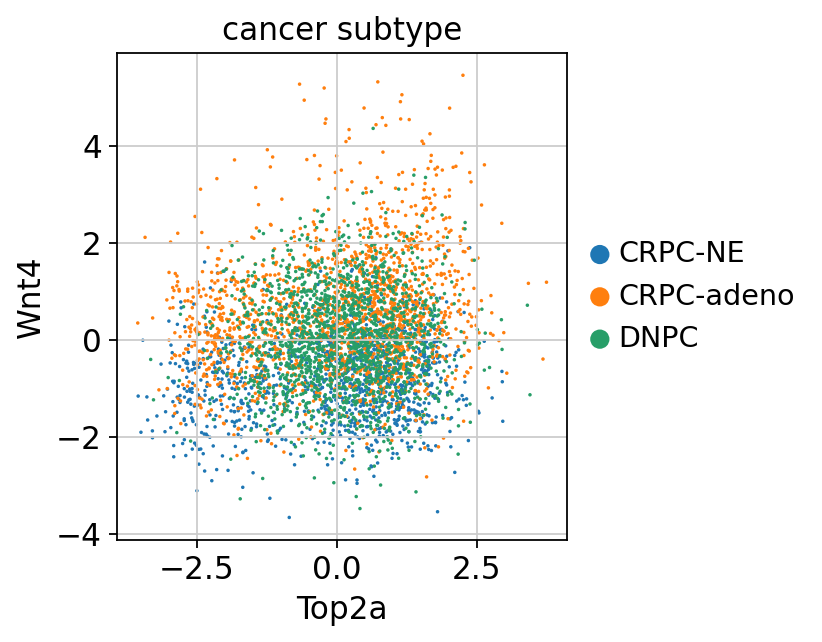

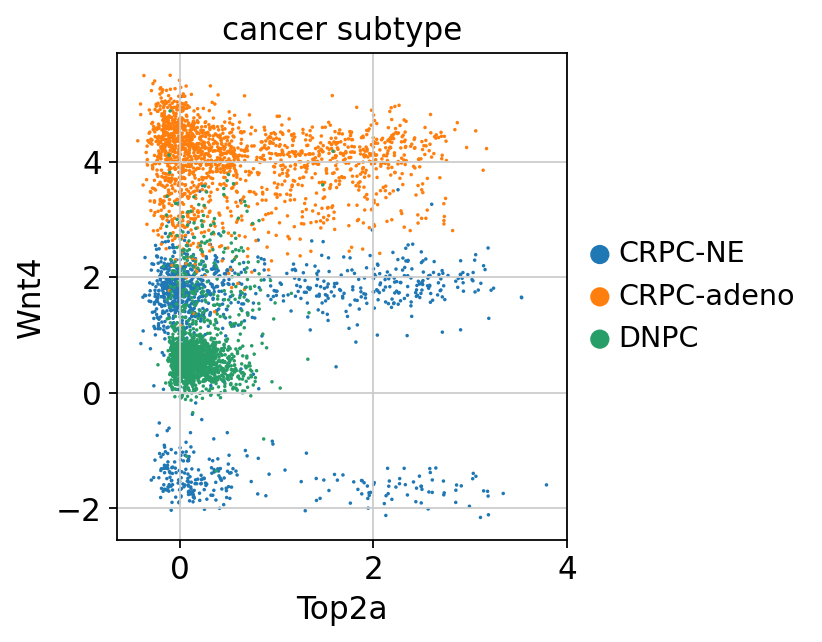

In [29]:
sc.pl.scatter(adata_gp, x='Top2a', y='Wnt4', color='cancer_subtype', size=10)
sc.pl.scatter(pyviperdata, x='Top2a', y='Wnt4', color='cancer_subtype', size=10)

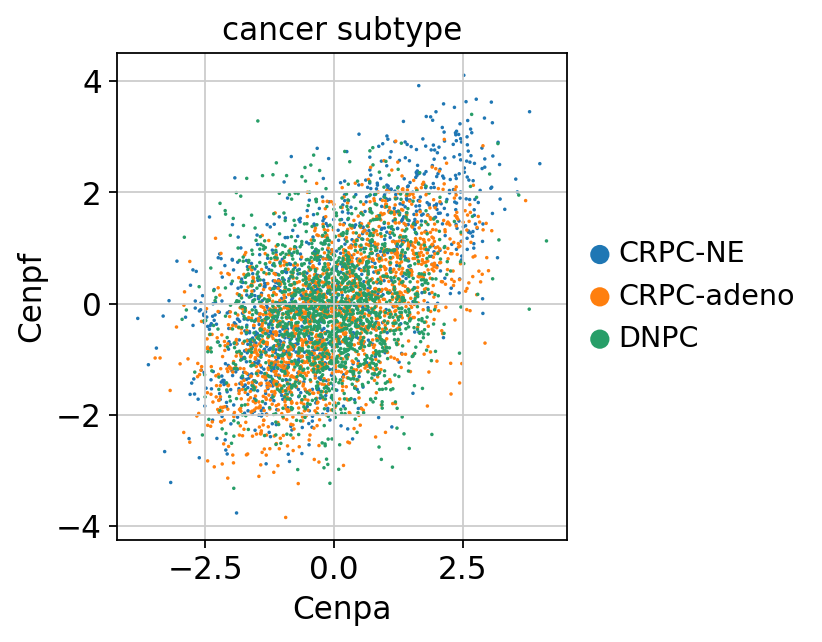

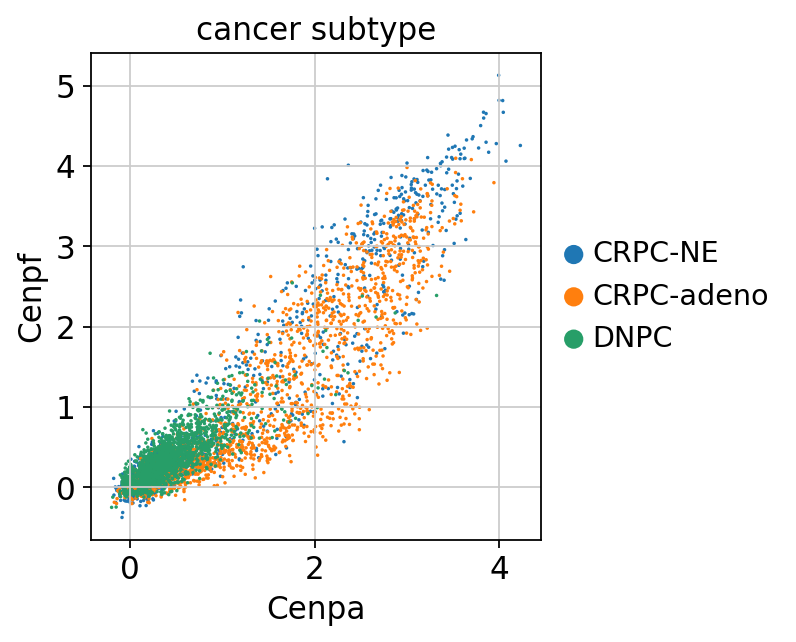

In [30]:
sc.pl.scatter(adata_gp, x='Cenpa', y='Cenpf', color='cancer_subtype', size=10)
sc.pl.scatter(pyviperdata, x='Cenpa', y='Cenpf', color='cancer_subtype', size=10)

In [ ]:
full_model = model.model
encoder = full_model.encoder
decoder = full_model.decoder

In [31]:
'''chga_genes = vae.term_genes('Chga', adata.uns['terms']).genes
genes_path = '/home/lgolinelli/git/scarches-1/notebooks/GRN-VAE/trained_models/genes_chga.npy'

np.save(
    genes_path,
    chga_genes
)'''

"chga_genes = vae.term_genes('Chga', adata.uns['terms']).genes\ngenes_path = '/home/lgolinelli/git/scarches-1/notebooks/GRN-VAE/trained_models/genes_chga.npy'\n\nnp.save(\n    genes_path,\n    chga_genes\n)"